# <span style="color:red"> QTM 151 - Practice Quiz </span>

<font size = "5">

Import pandas

In [ ]:
import pandas as pd
# 如果需要import其他的
import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

Quiz 4 第一题是
1. You will be given a code cell that calculates the coefficients of a quadratic model (y = ax^2 + bx + c) （约等于）between two variables. All code in this cell will be correct. Then in the next code cell, a figure is generated with a scatter plot of the individual data and a line plot of the model prediction. However, the plot is obviously wrong. Make necessary modifications to generate a correct plot.

In [ ]:
#答案模版框架
#可能顺序是乱的没有排序，那就要sort x
x_sorted = np.sort(x)
y_pred_sorted = a*x_sorted**2 + b*x_sorted + c
#回去看lecture 18的sort然后还有转换，有没有变成time啊等等

2. Read in a .csv file to create a DataFrame which contains weather data for Delhi, India in the year 2017. Using the ".plot()" method, generate a single line plot with (time vs. temperature) and (time vs. wind speed). The ".plot()" method is the one connected to a Pandas DataFrame, not the one in the matplotlib.pyplot library.

In [ ]:
# 读data就是
df_weather = pd.read_csv("/Users/macbook/Documents/GitHub/qtm151fall2025/.../ data_folder/HeightWeight-quiz.csv")
#画图的时候没有排序没关系，只要date是datetime类型在x上matplotlib会自动排序
# 先转换时间或者先check一下时间的type再看要不要转换
display(df_weather.dtypes) #显示类型
df_weather["date"] = pd.to_datetime(df_weather["date_str"])
display(df_weather.head())
# 然后:
# This will plot index vs. column 1 AND will plot index vs. column 2 
#plot默认折线图，如果想要改变就要plot(kind = "line / bar")这种
#想要加标题也可以直接plot(title = "S&P 500 and DJIA over time")或者直接设置一个新的名然后跟下面那个cell一样
df_weather[   ["date","sp500","djia"]   ].set_index("date").plot()

# .plot() used column names for the legend and x-axis.
# Here's how to adjust them ourselves

ax = df_financial[   ["date","sp500","djia"]   ].set_index("date").plot()
ax.set_title("S&P 500 and Dow Jones over Time")
ax.set_xlabel("Time")
ax.legend( ["S&P 500", "Dow Jones"] )
ax.set_ylabel("??????")
plt.show()

#也可以
df_financial[["date","sp500","djia"]].set_index("date").plot(
    title="S&P 500 and DJIA over time"
).set(xlabel="Date", ylabel="Index Value")

3. Read in a .csv file to create a DataFrame which contains conversion rates for Euros to U.S. dollars and British Pounds to U.S. dollars over time. Compute non-dimensional percentage growth values for each and plot together on a single plot. (You can use matplotlib.pyplot or the .plot() method connected to a DataFrame).

In [ ]:
df_currency = pd.read_csv("/Users/macbook/Documents/GitHub/qtm151fall2025/.../ data_folder/HeightWeight-quiz.csv")

df_currency["growth_euro"] = (df_currency["euro_to_usd"].diff() /
                              df_currency["euro_to_usd"].shift(1)) * 100

df_currency["growth_pound"] = (df_currency["pound_to_usd"].diff() /
                               df_currency["pound_to_usd"].shift(1)) * 100

# 绘图：两条线在同一张图上
plt.plot("date", "growth_euro",
         data = df_currency)

plt.plot("date", "growth_pound",
         data = df_currency, alpha = 0.75)
# alpha=0.75 让第二条线微微透明一点，避免两条重叠时看不清

# 添加坐标轴标签、标题
plt.xlabel("Time")
plt.ylabel("Daily percentage change")
plt.title("Change in Euro and Pound conversion rates")

# 添加图例
plt.legend(["Euro to USD", "Pound to USD"])
# legend 是图例，用于区分两条线代表的含义

# 显示图像
plt.show()

4. Continuing with the DataFrame of conversion rates, create a new column of Boolean type, which checks whether the conversion rate for one of the currencies was greater than a given value.

In [ ]:
#加入我们要检查欧元兑美元汇率是否大于1.08
df_currency["high_euro"] = df_currency["euro_to_usd"] > 1.08
#或者 df_currency["strong_euro"] = df_currency["euro_to_usd"].between(1.08, 10 / float("inf"))
#默认包含头尾
#如果不想包含头尾就要，inclusive=“left”只包含左边，“right”只包含右边，“neither”，“both”都不包含
display(df_currency[["date", "euro_to_usd", "high_euro"]])
display(df_currency.dtypes) 
#high_euro就会是bool

5. Continuing Problem 4, make a line plot of the conversion rate for this currency and highlight regions where the conversion rate is larger than a given value, using the function "plt.fill_between"

In [ ]:
# Create a line plot
plt.plot("date", "euro_to_usd", data=df_currency, label="_nolegend_") #也可以加color
plt.xlabel("Time")
plt.ylabel("Euro to USD Exchange Rate")
plt.title("Euro to USD Exchange Rate during the start of COVID/- Hightlight High Periods blabla")

# 这里就是 highlight 一段“高汇率”的时间区间（比如高于 1.08）
# Add a shaded region with a rectangle
# "x" 是横坐标（日期）
# "y1" 和 "y2" 是上下边界，这里用汇率的最小值和最大值填充
# "where" 就是boolean，True 的地方会被上色

x_vals = df_currency["date"]
y_vals = df_currency["euro_to_usd"]
condition = df_currency["euro_to_usd"] > 1.08   # 比如高于 1.08 时高亮

plt.fill_between(x = x_vals,
                 y1 = y_vals.min(),
                 y2 = y_vals.max(),
                 where = condition,
                 alpha = 0.2,color = "red",
                 label="Periods of large Rate > 1.08" )

plt.legend()
plt.show()

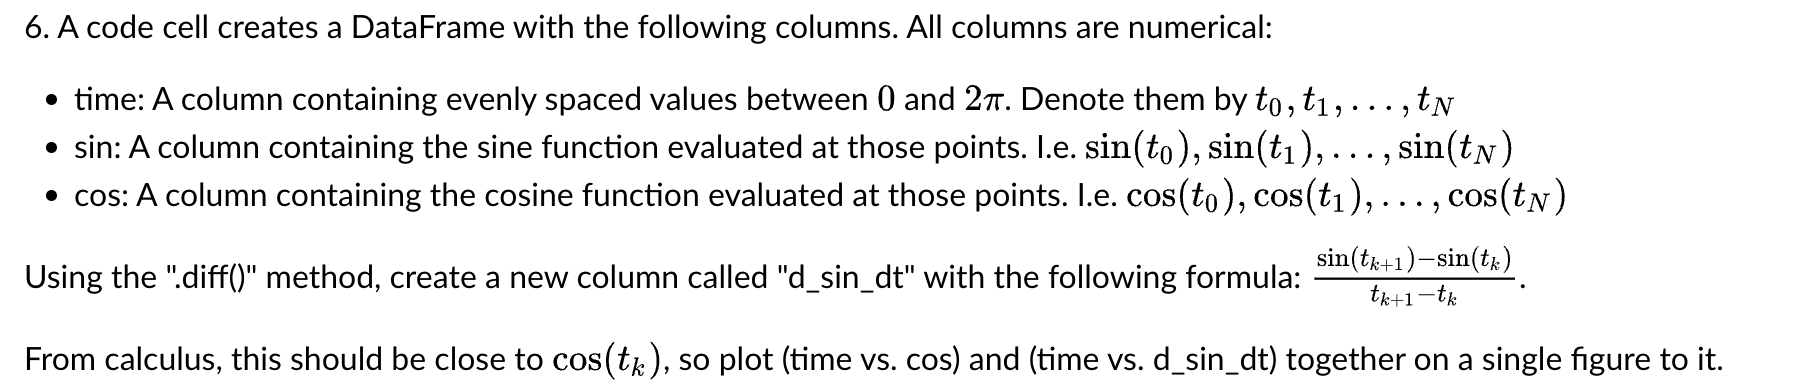

In [ ]:
# Using the .diff() method, create new column for derivative of sin(t)
df["d_sin_dt"] = df["sin"].diff() / df["time"].diff()

# Plot time vs cos(t) and time vs d_sin_dt on the same figure
ax = df[["time", "cos", "d_sin_dt"]].set_index("time").plot()

# Set chart title
ax.set_title("cos(t) vs. numerical derivative of sin(t)")

# Label x-axis
ax.set_xlabel("Time")

# Label y-axis
ax.set_ylabel("Function Value")

# Add legend
ax.legend(["cos(t)", "d_sin_dt"])

# Display the plot
plt.show()


<font size = "5">

(1) Replace the values of a column

<font size = "3">

- Consider the DataFrame ``df_movies`` created below.
- In the "country" column, change the values "American" and "Korean" to "USA" and "ROK" respectively
- Do this by using the ``.replace`` method.

In [ ]:
# create example DataFrame - don't change this
titles = ["Past Lives", "Citizen Kane", "Revenge", "Okja", "Shutter", 
    "A Tale of Two Sisters", "La Chinoise", "The Umbrellas of Cherbourg", "House",
    "Suspiria", "Blue Velvet"]
# 定义电影标题列表，用于 DataFrame 的 'title' 列

country = ["American", "American", "France", "Korean", "Thailand", "Korean", "France",
    "France", "Japan", "Italy", "American"] 
# 国家列表，对应每部电影
runtime = [106, 119, 108, 120, 97, 115, 96, 91, 88, 98, 120] # 每部电影的时长（分钟）
year = [2023, 1941, 2017, 2017, 2004, 2003, 1967, 1964, 1977, 1977, 1986] #上映时间
movie_dict = {"title" : titles, "country" : country, "runtime" : runtime, "year" : year}
# 将多个列表组合为键值对（列名: 列数据），按照index一一对应，所以上面的list长度都要一致

df_movies = pd.DataFrame(movie_dict)
# 使用 pandas.DataFrame() 将字典转换为表格结
print(df_movies)

# your answer here
df_movies["country"] = df_movies["country"].replace(["American", "Korean"], 
                            ["USA", "ROK"])
# replace（前面是要被replace的； 逗号后面的是要replace成什么）
#前面那段就是其实就是在把修改后的结果重新赋值回原来的那一列。

print()
print(df_movies)

                         title   country  runtime  year
0                   Past Lives  American      106  2023
1                 Citizen Kane  American      119  1941
2                      Revenge    France      108  2017
3                         Okja    Korean      120  2017
4                      Shutter  Thailand       97  2004
5        A Tale of Two Sisters    Korean      115  2003
6                  La Chinoise    France       96  1967
7   The Umbrellas of Cherbourg    France       91  1964
8                        House     Japan       88  1977
9                     Suspiria     Italy       98  1977
10                 Blue Velvet  American      120  1986

                         title   country  runtime  year
0                   Past Lives       USA      106  2023
1                 Citizen Kane       USA      119  1941
2                      Revenge    France      108  2017
3                         Okja       ROK      120  2017
4                      Shutter  Thailand       

1. You will load in a .csv, creating a DataFrame. In one of the columns, there are 3 values that need to be replaced with 3 new values. You will be asked to do this using the .replace method once.

In [ ]:
# 读data的话就是下面这个
# df = pd.read_csv("/Users/macbook/Documents/GitHub/qtm151fall2025/.../ data_folder/HeightWeight-quiz.csv")
# print(df.head()) 检查
# 假设列名是 'Category'，其中有 3 个旧值需要替换成新值
df["Category"] = df["Category"].replace(           # 使用 .replace() 批量替换值
    ["OldValue1", "OldValue2", "OldValue3"],       # 要被替换的旧值列表 (old values不是string不用“”)
    ["NewValue1", "NewValue2", "NewValue3"] )      # 对应的新值列表 (new values)

<font size = "5">

(2) Recode a numeric column

<font size = "3">

- Consider the DataFrame ``df_movies`` created above
- Recode the "year" column into a new column "year_brackets" <br>
with the following categories:

$\qquad$ ``` ["1941-1967","1968-1999","2000-onwards"] ```

$\qquad$ HINT: Use the "pd.cut()" command.

In [ ]:
# your code here
df_movies["year_brackets"] = pd.cut(x = df_movies["year"], 
                bins=[1940, 1967, 1999, float("inf")], # bins是左边不包括右边包括所以1940就是1941才开始
                labels = ["1941-1967", "1968-1999", "2000-onwards"]) 
# labels长度必须比 bins 少 1。因为bins多一个头尾，labels少一个区间
# 用pd.cut() 把连续数值分组，生成新的分类列，这里要分参数x（year）。
print(df_movies)

#可以把这个当正式quiz第三题的模版
# You will recode a numeric variable into a categorical variable (which takes string values). 
# The category will be based on which interval the numeric variable belongs to.

                         title   country  runtime  year year_brackets
0                   Past Lives       USA      106  2023  2000-onwards
1                 Citizen Kane       USA      119  1941     1941-1967
2                      Revenge    France      108  2017  2000-onwards
3                         Okja       ROK      120  2017  2000-onwards
4                      Shutter  Thailand       97  2004  2000-onwards
5        A Tale of Two Sisters       ROK      115  2003  2000-onwards
6                  La Chinoise    France       96  1967     1941-1967
7   The Umbrellas of Cherbourg    France       91  1964     1941-1967
8                        House     Japan       88  1977     1968-1999
9                     Suspiria     Italy       98  1977     1968-1999
10                 Blue Velvet       USA      120  1986     1968-1999


<font size = "5">

(3) Rename column

<font size = "3">

- Consider the DataFrame ``df_movies`` created above
- Rename the column "runtime" to "runtime(minutes)"

In [ ]:
# Write your answer here:
#前面不要加blabla = 不然就是一个新的dataframe副本，不会改变原来的对象

#考试就用下面这个原地修改 所以要inplace = True，就是意思是不返回新的结果。左边是本来的 右边是要改成的
df_movies.rename(columns={"runtime" : "runtime(minutes)"}, inplace=True)

print(df_movies)

#当quiz第五题模版
# Rename one of the column/variable headings of a DataFrame, 
# leaving the others unchanged.

                         title   country  runtime(minutes)  year year_brackets
0                   Past Lives       USA               106  2023  2000-onwards
1                 Citizen Kane       USA               119  1941     1941-1967
2                      Revenge    France               108  2017  2000-onwards
3                         Okja       ROK               120  2017  2000-onwards
4                      Shutter  Thailand                97  2004  2000-onwards
5        A Tale of Two Sisters       ROK               115  2003  2000-onwards
6                  La Chinoise    France                96  1967     1941-1967
7   The Umbrellas of Cherbourg    France                91  1964     1941-1967
8                        House     Japan                88  1977     1968-1999
9                     Suspiria     Italy                98  1977     1968-1999
10                 Blue Velvet       USA               120  1986     1968-1999


<font size = "5">

(4) Merge dataset

<font size = "3">

- Consider the DataFrames ``df_movies`` (created above) and ``df_scores`` (created below)
- Create a new dataset using  ```pd.merge()``` using <br>
"df_movies" as the primary dataset, and <br>
"df_scores" as the secondary dataset, merging on <br>
the column "title"
- You should **ONLY** merge the "imdb_score" column <br>
from the secondary dataset (not the "director" column)

HINT: Use ```[[...]]``` to extract a subset of columns <br>
from the secondary dataset before merging

In [ ]:
# create example DataFrame - don't change this
titles = ["Past Lives", "Citizen Kane", "Revenge", "Okja", "Shutter", 
    "A Tale of Two Sisters", "La Chinoise", "The Umbrellas of Cherbourg", "House",
    "Suspiria", "Blue Velvet"]
scores = [7.8, 8.2, 6.4, 7.3, 7.0, 7.1, 6.9, 7.8, 7.2, 7.3, 7.7]
directors = ["Celine Song", "Orson Welles", "Coralie Fargeat", "Bong Joon Ho", 
    "Banjong Pisanthanakun", "Kim Jee-woon", "Jean-Luc Godard", "Jacques Demy", 
    "Nobuhiko Obayashi", "Dario Argento", "David Lynch"]

movie_dict2 = {"title" : titles, "imdb_score" : scores, "director" : directors}
df_scores = pd.DataFrame(movie_dict2)

# Write your answer here:

df_new = pd.merge(left = df_movies, right = df_scores[["title", "imdb_score"]], # 只带需要的列
        on = "title", how = "left")
print(df_new)

# 当考试第六题的模版
#left是primary，right是secondary，merging on 就是on=
#如果两边on的列名不一样比如df_movies` 有列叫 "title"， df_scores` 有列叫 "movie_title"
#原来on的位置就left_on="title", right_on="movie_title"
#how="left" 左连接：保留左表（主表）所有行。右表匹配不上时，新增列显示为 NaN。
# Merge two DataFrames. After merging, the primary DataFrame will have one new column that is obtained from the secondary DataFrame.

                         title   country  runtime(minutes)  year  \
0                   Past Lives       USA               106  2023   
1                 Citizen Kane       USA               119  1941   
2                      Revenge    France               108  2017   
3                         Okja       ROK               120  2017   
4                      Shutter  Thailand                97  2004   
5        A Tale of Two Sisters       ROK               115  2003   
6                  La Chinoise    France                96  1967   
7   The Umbrellas of Cherbourg    France                91  1964   
8                        House     Japan                88  1977   
9                     Suspiria     Italy                98  1977   
10                 Blue Velvet       USA               120  1986   

   year_brackets  imdb_score  
0   2000-onwards         7.8  
1      1941-1967         8.2  
2   2000-onwards         6.4  
3   2000-onwards         7.3  
4   2000-onwards         7.0

<font size = "5">

(5) Aggregate and sort

<font size = "3">

- Using the merged dataset you created above, do the following in a single line by chaining:
    - Group the dataset by "country"
    - Aggregate the following statistics: average runtime, maximum runtime, average IMDB score, minimum IMDB score
    - Score by average IMBD score in **descending order**

Print the resulting DataFrame



In [ ]:
# Write your answer here:
#（df前面也可以加一个名字比如top_groups = 
# as_index = False看情况，应该是不用如果要用就对应在country后面这个位置
(df_new.groupby("country").agg(avg_run = ('runtime(minutes)', 'mean'),
                    max_run = ('runtime(minutes)', 'max'),
                    avg_imdb = ('imdb_score', 'mean'),
                    min_imdb = ('imdb_score', 'min')).
                    sort_values(by = "avg_imdb", ascending = False)
                    #取前几个的话这一行就写.head(5) 
                    )

#当正式quiz 第四题模版
#4. You will be asked to do the following: group a dataset by one of its columns/variables,
# aggregate one or more statistics for each group, 
# and then sort the data by one of the statistics you aggregated over in descending order. 
# Full credit will be given if you can do this in 1 line using chaining.


,avg_run,max_run,avg_imdb,min_imdb
country,,,,
USA,115.000000,120,7.900000,7.7
Italy,98.000000,98,7.300000,7.3
Japan,88.000000,88,7.200000,7.2
ROK,117.500000,120,7.200000,7.1
France,98.333333,108,7.033333,6.4
Thailand,97.000000,97,7.000000,7.0


<font size = "5">

(6) Query and Aggregate

<font size = "3">

Using the merged dataset you created above, do the following in a single line by chaining:

- Subset the observations for 'country == France' using ```.query()```
- Sort the values by year (oldest first)
- Extract the two oldest movies

Print the resulting DataFrame to the screen

In [ ]:
# Write your answer here:

df_new.query("country == 'France'").sort_values(by = "year").iloc[:2,:]
# 从整张表里只留下法国的电影,按照年份最早的在最上面，取前面两行

#正式quiz第二题也可以参考这个
# Note: "filtering" is often the word used to obtain a subset
#考试可以看lecture 16

,title,country,runtime(minutes),year,year_brackets,imdb_score
7,The Umbrellas of Cherbourg,France,91,1964,1941-1967,7.8
6,La Chinoise,France,96,1967,1941-1967,6.9


2. You will need to extract a subset of the data based on a logical condition. You will then group this subset, and aggregate one or more statistics. Then you will extract a subset of this data, based on where one of the aggregated statistics is greater than or equal to some value. Full credit will be given if you can do this in 1 line using chaining.

In [ ]:
teamrace_agg500 = (df_results.query("raceId >= 500") #先subset
                       .groupby(["raceId","constructorId"]) #再group，as_index = False暂时应该不用
                        .agg(mean_points = ('points','mean'), #再aggregate
                             sd_points =   ('points','std'),
                             min_points =  ('points','min'),
                             max_points =  ('points','max'),
                             cars_entered   = ('points',len))
                        .query("mean_points >= 10") #再subset一遍
                    )
display(teamrace_agg500)